# Combining data through transfer learning Bayesian optimization (TLBO)

Owing thanks to our diligent use of Bayesian optimization, Ms. Dixon has saved up a small fortune for a holiday to the Swiss Alps. She can even afford to ski and buy one or two small coffees! She leaves mining operations to her son Rikard while she is away. 

Unfortunately, on the first day of operations Rikard quotes the wrong password for the company database to the team. Hoping not to embarrass himself, Rikard instructs the team three times in a row to enter this password into login portal. Disaster seems to ensue as the team have been locked out for seven days.

Fortunately, Rikard's segacity is as great a resource as his forgetfulness. He lets the team know they can use handwritten records of approximate gold yields as well as the truck's black box for approximate dig sites. The yields will be noisy and the truck's internal map was never quite configured properly. It is our task to get the most out of this dataset using transfer learning Bayesian optimization (TLBO). 

## The true gold map and Rikard's best reconstruction of Ms Dixon's results

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ProcessOptimizer as po
from ProcessOptimizer.model_systems import get_model_system

# The paramters that control the bias due to Rikard's truck's black box
compass_offset = 0.2
shift_offset = [0.1, 0]

# The parameter that controls the noise in the gold yield approximations
approximation_error_size = 0.02

# Rikard's best representation of Ms Dixon's previous digs. The map is rotated and shifted and the scores are noisy.
rikards_old_records = get_model_system('candidate_gold_map', rotate=compass_offset, shift=shift_offset)
rikards_old_records.set_noise_model("constant")
rikards_old_records.noise_model.set_noise_type("Gaussian")
rikards_old_records.noise_size = approximation_error_size
rikards_old_bounds = rikards_old_records.space.bounds

# The gold map as Ms Dixon and Rikard record themselves.  
true_gold_map = get_model_system("gold_map")
true_bounds = true_gold_map.space.bounds

coordinates = [(0.0, 15.0), (0.0, 15.0)]

### Viewing the true and reconstructed gold maps

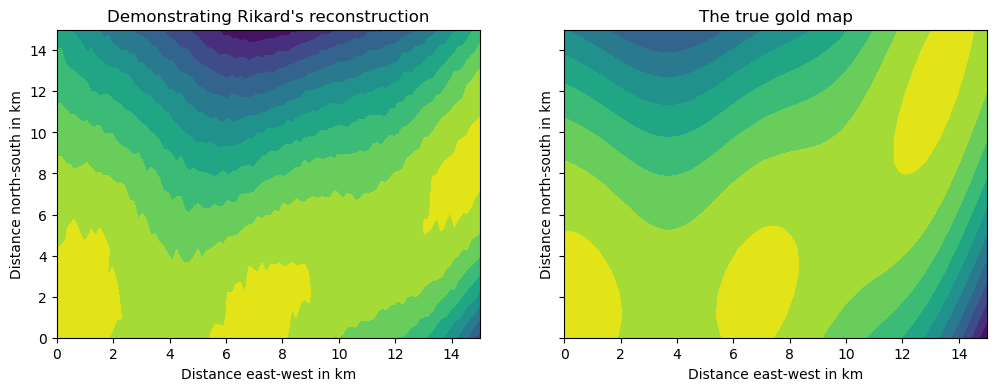

In [2]:
x_list = np.linspace(coordinates[0][0],coordinates[0][1],100)
y_list = np.linspace(coordinates[1][0],coordinates[1][1],15,100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

(x_mesh,y_mesh) = np.meshgrid(x_list,y_list)
mesh_values = lambda score_fcn: [[-score_fcn.get_score((x,y)) for (x,y) in zip(x_vec,y_vec)] 
                for (x_vec,y_vec) in zip(x_mesh,y_mesh)]

for ax_, score_fcn_, title_ in zip(ax.flatten(), 
                                       [rikards_old_records, true_gold_map], 
                                       ["Demonstrating Rikard's reconstruction", "The true gold map"]):
    ax_.contourf(x_mesh,y_mesh, mesh_values(score_fcn_), 10)
    ax_.set_xlabel("Distance east-west in km")
    ax_.set_ylabel("Distance north-south in km")
    ax_.set_title(title_)

**Remember that these maps are still SECRET. Our prospectors only learn their values at specific points. If Ms. Dixon had collected a lot of data, Rikard's reconscruction would look something like the map on the left. Nonetheless, Rikard will collect new data and mine gold according to the map on the right.**

**Notice also that Rikard's reconstruction is biased (especially in the top right) due to an affine transformation, as well as noisy due to random error.**

## Ms. Dixon's data collection procedure and the results reconstructed by Rikard

We run a simulation of Ms Dixon's Bayesian optimization routine that set up identically to the first 10 digs in walkthrough 01 (how far we've come!). Recall our usage of the `optimizer` and its `ask()`, `score()` and `tell()` methods. 

Amount of gold found:  2.8474483459296933
ProcessOptimizer suggests Ms. Dixon starts by digging at [np.float64(8.25), np.float64(6.75)]
ProcessOptimizer knows about a dig at [np.float64(8.25), np.float64(6.75)] where 2.9075138389633866 mg of gold was found.
Ms. Dixon's team dug at [np.float64(9.75), np.float64(12.75)] and found 2.383000334977373 mg of gold
Ms. Dixon's team dug at [np.float64(0.75), np.float64(3.75)] and found 3.0540778601201697 mg of gold
Ms. Dixon's team dug at [np.float64(11.25), np.float64(9.75)] and found 2.9342972315339106 mg of gold
Ms. Dixon's team dug at [np.float64(5.25), np.float64(8.25)] and found 2.4920747212346397 mg of gold
Ms. Dixon's team dug at [np.float64(3.75), np.float64(14.25)] and found 1.1032380415759875 mg of gold
Ms. Dixon's team dug at [np.float64(6.75), np.float64(11.25)] and found 2.255901029131492 mg of gold
Ms. Dixon's team dug at [np.float64(14.25), np.float64(5.25)] and found 2.072676888639817 mg of gold
Ms. Dixon's team dug at [np.float

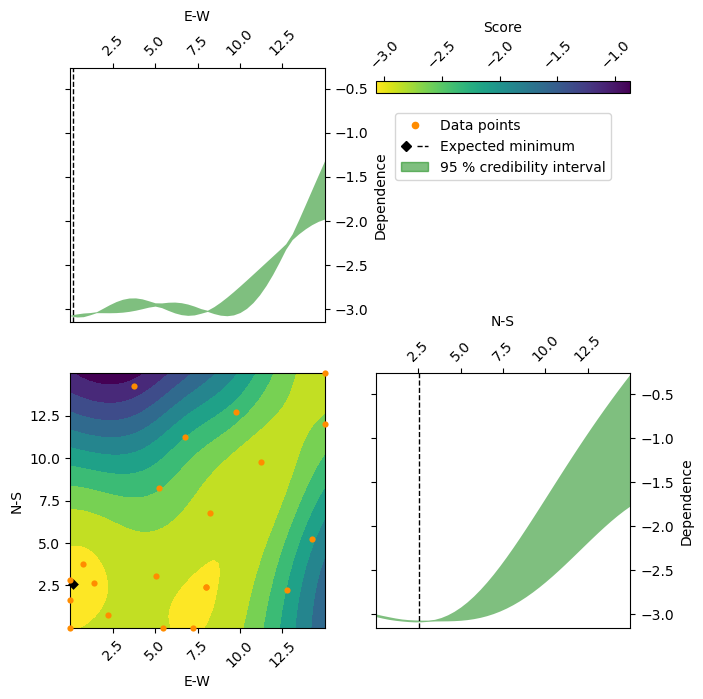

In [3]:
first_gold_found = true_gold_map.get_score([7.5,7.5])
print("Amount of gold found: ", -first_gold_found)

# Starting the ProcessOptmizer, and telling it about our plot of land
opt_Ms_Dixon = po.Optimizer(dimensions=coordinates)
# Finding the first position
new_coordinates = opt_Ms_Dixon.ask()
print(f"ProcessOptimizer suggests Ms. Dixon starts by digging at {new_coordinates}")
# Digging at the suggested coordinates
gold_found = true_gold_map.get_score(new_coordinates)
# Telling the ProcessOptimizer about how much gold we found
opt_Ms_Dixon.tell(new_coordinates, gold_found)
print(f"ProcessOptimizer knows about a dig at {opt_Ms_Dixon.Xi[0]} where {-opt_Ms_Dixon.yi[0]} mg of gold was found.")

Ms_Dixon_BO_digs = 20

# For each of the next 10 positions
for index in range(Ms_Dixon_BO_digs-1):
    # Find the place to dig
    new_dig_site = opt_Ms_Dixon.ask()
    # Digging for gold
    gold_found = true_gold_map.get_score(new_dig_site)
    # Telling the optimiser how uch gold we found
    result_Ms_Dixon = opt_Ms_Dixon.tell(new_dig_site, gold_found)
    print(f"Ms. Dixon's team dug at {new_dig_site} and found {-gold_found} mg of gold")

# Telling the optimiser about the very first dig
result_Ms_Dixon = opt_Ms_Dixon.tell(new_dig_site, gold_found)
# plotting
po.plot_objective(result=result_Ms_Dixon,pars="expected_minimum",dimensions = ["E-W","N-S"]);

**This should look familiar: it's the result of Ms. Dixon's first ten digs**

## Depiciting what Rikard sees when he reconstructs these digs by Ms. Dixon

Original dig site as recorded by Ms. Dixon:
[8.00913426 2.43260328]
Original dig site as recorded by the truck's black box:
[8.23476182 0.81281076]
Original yield as recorded by Ms. Dixon:
3.023083113082907
Approximate original yield, handwritten on site:
3.0567296427187274


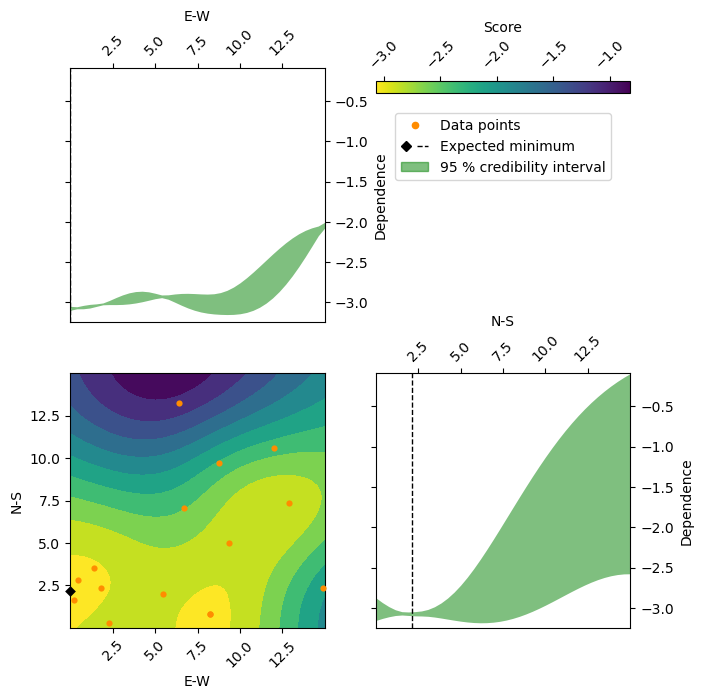

In [4]:
dig_sites_true = np.array(opt_Ms_Dixon.Xi)
yields_true = np.array(opt_Ms_Dixon.yi)

# Dig sites as recorded by the truck's black box
theta = - compass_offset
dig_sites_black_box = (dig_sites_true - shift_offset) @ np.array([[np.cos(theta),  - np.sin(theta)], [np.sin(theta), np.cos(theta)]]).T

still_in_map_indices = [i for i in range(len(dig_sites_black_box-1)) if 0 <= dig_sites_black_box[i][0] <= 15 and 0 <= dig_sites_black_box[i][1] <= 15]
dig_sites_black_box = dig_sites_black_box[still_in_map_indices]

num_digs_rikard_sees = len(still_in_map_indices)

# Approximate yields recorded onsite and known by Rikard's team
yields_approximate = [rikards_old_records.get_score(site) for site in dig_sites_black_box]

print("Original dig site as recorded by Ms. Dixon:")
print(dig_sites_true[-1])

print("Original dig site as recorded by the truck's black box:")
print(dig_sites_black_box[-1])

print("Original yield as recorded by Ms. Dixon:")
print(-yields_true[-1])

print("Approximate original yield, handwritten on site:")
print(-yields_approximate[-1])

# How Rikard would view Ms. Dixon's findings if he didn't know there was a fault with his records
opt_Rikard_biased = po.Optimizer(dimensions=coordinates)

result_rikard = opt_Rikard_biased.tell(dig_sites_black_box, yields_approximate)

#plotting
po.plot_objective(result=result_rikard,pars="expected_minimum",dimensions = ["E-W","N-S"]);

**Rikard's conclusions are not the same but are clearly related to Ms. Dixon's** 

## Rikard's transfer learning Bayesian optimization experiment (in XpyriMentor)

We will now show that Rikard can improve on Ms. Dixon's best yield in fewer experiments than Ms. Dixon. He will do this by incorparating his reconstructed data into his decision making procedure through transfer learning Bayesian optimization (TLBO). 

Currently, TLBO is supported in ProcessOptimizer by the XpyriMentor workflow. The following code will look slightly different to previous walkthroughs, which utilize the Optimizer workflow. We use this workflow so we can define our choices of training and test task as well as to set up an appropriate model for transfer learning. The basic functions used in optimization and analysis, `ask()`, `tell()` and `plot_objective()` remain the same. 

### Setting up XpyriMentor for transfer learning BO

Here we set up a coordinate space for Rikard, which consists of two 15×15 squares. The first square will correspond to the (biased) predictions he can make from Ms. Dixon's previous work. The second corresponds to the unbiased digs he will perform over the week. A `task` dimension will tells us that these squares are labelled `0` and `1` and that `1` is Rikard's digging task.

**Entering Rikard's initial data:** We will also enter Rikard's reconstructed dataset and some initial digging experiments. 

Rikard does not know a priori how poor his reconstruction is. On the first two days of Rikard's team's work, they will dig randomly to gain a sense of how closely the reconstruction and the ground truth align. 

In [5]:
# Necessary functionality from XpyriMentor for TLBO
from ProcessOptimizer import XpyriMentor 
from ProcessOptimizer.XpyriMentor.suggestors import MTSuggestor

# There is an extra entry '[0,1,{1}]' which does not appear in the variable 'coordinates' above.
# This entry means there are two 'tasks', labelled 0 and 1, and '{1}' indicates that task 1 is Rikard's task. 
multitask_space = po.Space([(0.0, 15.0), (0.0, 15.0), [0,1,{1}]])

# A multitask 'suggestor' which includes default TLBO settings based on our 'multitask_space'.
RikardsMTSuggestor = MTSuggestor(multitask_space, 1, 42)

# An 'XpyriMentor' which handles ask(), tell() and plot_objective().
RikardsMentor = XpyriMentor(multitask_space, RikardsMTSuggestor)

print(f"These are the defaults for our suggestor: {RikardsMTSuggestor.kwargs}")

#                                      #
#    Entering Rikard's initial data    #
#                                      #

# XpyriMentor is a maximizer, unlike Optimizer which is a minimizer
yields_approximate_positive = [-yield_i for yield_i in yields_approximate]

# Tell Rikard's XpyriMentor about the reconstructed data
RikardsMentor.tell(x = dig_sites_black_box, 
                   y = np.array(yields_approximate_positive),
                  task = 0)

#                                      #
#          Random experiments          #
#                                      #

# Randomly chosen digs to approximate how close the reconstruction is to true map
num_random_digs = 2

random_dig_sites = np.random.uniform(low = 0.0,
                                     high = 15.0,
                                     size = (num_random_digs, 2)
                                    )

test_random_gold_scores = [-true_gold_map.get_score(dig_site_i) for dig_site_i in random_dig_sites]

# Tell Rikard's XpyriMentor about the random test digs
RikardsMentor.tell(x = random_dig_sites, 
                   y = np.array(test_random_gold_scores), 
                   task = 1)

These are the defaults for our suggestor: {'surrogate_kwargs': {'task_feature': 2, 'type': 'multitask', 'test_task': 1, 'mean_module': ConstantMean(), 'covar_relative_lengthscale': 0.2, 'covar_module': ScaleKernel(
  (base_kernel): RBFKernel(
    (raw_lengthscale_constraint): Positive()
  )
  (raw_outputscale_constraint): Positive()
), 'likelihood': GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)}, 'acq_func_kwargs': {'xi': 0.01, 'acq': 'qLogExpectedImprovement'}}


### Optimizing for the remaining days

Rikard and the team will spend the remaining four days utilizing transfer learning Bayesian optimization. We will see whether the team can perform as well as, or possibly outperform, Ms. Dixon's best results. This would be a significant result for the following two reasons: (1) Rikard had only seven days of experiments, unlike Ms. Dixon who had eleven; (2) Rikard spent three days digging with no strategy to find out how closely his task aligns with his reconstruction of Ms. Dixon's data. 

In [6]:
# Rikard already spent the first three days of the experiment digging uniformly at random
Rikards_remaining_days = 19

for day in range(Rikards_remaining_days): 

    next_dig_site = RikardsMentor.ask()

    next_yield = [-true_gold_map.get_score(next_dig_site[0])]

    RikardsMentor.tell(x = next_dig_site, y = next_yield, task = 1)


active_task_indices = np.where(np.stack(RikardsMentor.Xi)[:, RikardsMentor.suggestor.kwargs['surrogate_kwargs']['task_feature']] == 1)[0]
best_yield_rikard = max(np.stack(RikardsMentor.yi)[active_task_indices])

num_days_Rikard = len(active_task_indices)

best_yield_Ms_Dixon = -result_Ms_Dixon.fun

print(f"Best yield recorded in Ms Dixon's {Ms_Dixon_BO_digs+1} days: {best_yield_Ms_Dixon}")

print(f"Best yield recorded in Rikard's {num_days_Rikard} days: {best_yield_rikard}")

if best_yield_rikard > best_yield_Ms_Dixon and num_days_Rikard <= Ms_Dixon_BO_digs+1: 
    print("*")
    print("*")
    print("*")
    print("GREAT SUCCESS RIKARD! Ms Dixon will be proud:)")
    print("*")
    print("*")
    print("*")
    print(f"We have uncovered a digging spot that is better than Ms. Dixon's best known spot, and in only {num_days_Rikard} days. We can thank transfer learning.")

# print(best_yield_rikard)

Best yield recorded in Ms Dixon's 21 days: 3.0726745976993475
Best yield recorded in Rikard's 21 days: 3.089909315109253
*
*
*
GREAT SUCCESS RIKARD! Ms Dixon will be proud:)
*
*
*
We have uncovered a digging spot that is better than Ms. Dixon's best known spot, and in only 21 days. We can thank transfer learning.


### Plotting Rikard's posterior over the best dig sites

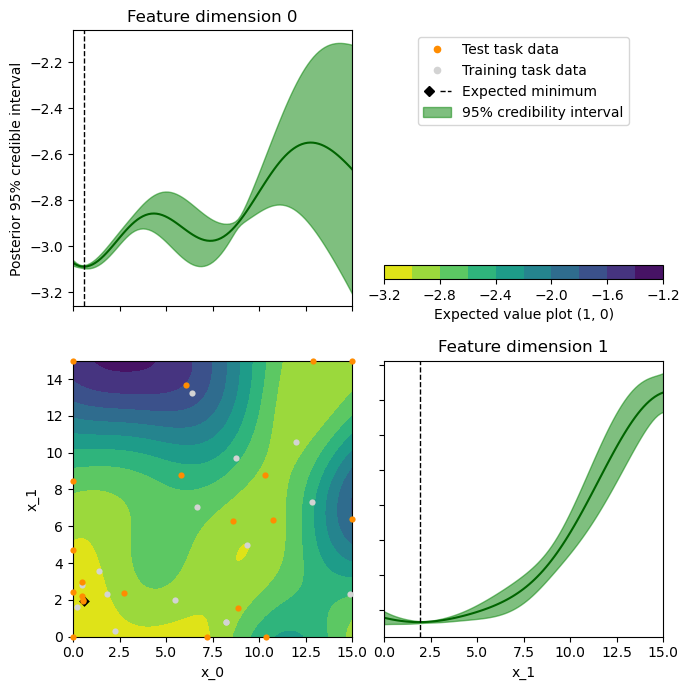

In [7]:
RikardsMentor.plot_objective()

# Benchmarking Experiments - proving transfer learning reliably gives better results

Here we reproduce the experiments above many times over and construct convergence plots to show that with increasing training size we get closer to the optimal yield. While there is a lot of code, this is essentially a repeat of what we have done above. There are some extra lines for keeping track of best results between experiments and repeating the entire procedure many times to show TLBO reliably outperforms starting from scratch. 

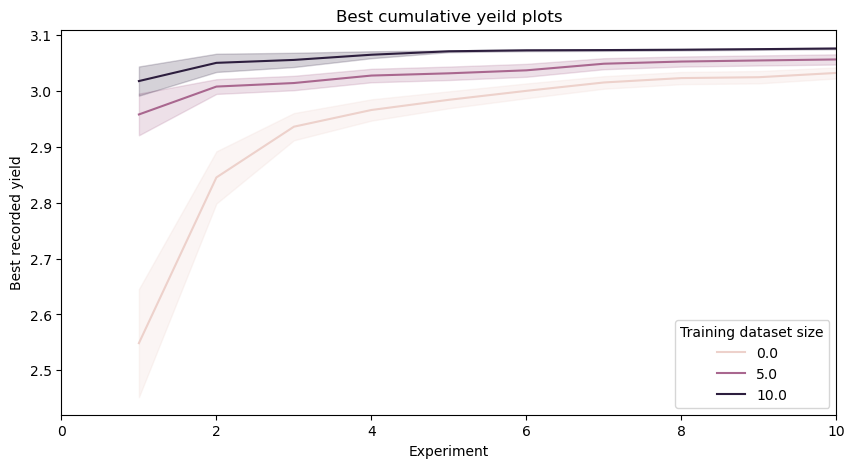

In [8]:
# For storing and plotting convergence results
import pandas as pd
import seaborn as sns
import warnings

results = pd.DataFrame(columns=["Experiment", "Best recorded yield", "Training dataset size"])

#                                      #
#         Sweep of experiments         #
#                                      #

# How many repeats to get standard errors
whole_experiment_iterations = 30

# How many random digs to initialize the learning of the test function
test_DOE_size = 2

# How many BO experiments on test function
test_experiments = 10

# Size of training dataset for TLBO
training_data_sizes = np.array([5, 10])

#                                      #
#         Baseline comparisons         #
#                                      #

test_baseline_experiments = test_experiments + test_DOE_size

for repeat in range(whole_experiment_iterations):

    # Reproducible seed with different results between repeats
    rng_seed = repeat
    
    # Baseline comparison with single task BO, where we ignore training data
    opt_baseline = po.Optimizer(dimensions=coordinates, random_state=rng_seed)

    # # Select initial points with latin hypercube sampling based on different random seeds
    # initial_digs = opt_baseline.space.lhs(n=test_DOE_size, seed=rng_seed)

    # Keep track of best dig so far for the baseline comparison
    cum_best_baseline = np.zeros(test_baseline_experiments)
    
    # Same loop as Ms. Dixon's example
    for experiment in range(test_baseline_experiments):
        
        new_dig_site = opt_baseline.ask()
        
        gold_found = true_gold_map.get_score(new_dig_site)

        result_baseline = opt_baseline.tell(new_dig_site, gold_found)
        
        # Store cumulative best results
        curr_best_dig = -result_baseline.fun
        results.loc[len(results)] = [experiment + 1, curr_best_dig, 0]

    # Delete baseline optimizer once used
    del opt_baseline

#                                      #
#           TLBO simulations           #
#                                      #

for repeat in range(whole_experiment_iterations):

    # Reproducible seed with different results between repeats
    rng_seed = repeat

    for training_size in training_data_sizes:

        multitaskSuggestor = MTSuggestor(multitask_space, 1, rng_seed)

        # multitaskSuggestor.kwargs['acq_func_kwargs']['acq'] = 'qExpectedImprovement'
        
        benchmarkMentor = XpyriMentor(multitask_space, multitaskSuggestor)

        #                                      #
        #           Training dataset           #
        #                                      #
        
        opt_baseline = po.Optimizer(dimensions=coordinates)

        # Reproducible seed with different results between repeats
        rng_seed = repeat

        # Same loop as Ms. Dixon's example
        for training_experiment in range(training_size):
            new_dig_site = opt_baseline.ask()
            gold_found = true_gold_map.get_score(new_dig_site)
            result_baseline = opt_baseline.tell(new_dig_site, gold_found)

        dig_sites_true = np.array(opt_baseline.Xi)
        yields_true = np.array(opt_baseline.yi)

        # Delete baseline optimizer once used
        del opt_baseline

        # Same as Rikard's reconstruction
        dig_sites_black_box = (dig_sites_true - shift_offset) @ np.array([[np.cos(theta),  - np.sin(theta)], [np.sin(theta), np.cos(theta)]]).T
        still_in_map_indices = [i for i in range(len(dig_sites_black_box-1)) if 0 <= dig_sites_black_box[i][0] <= 15 and 0 <= dig_sites_black_box[i][1] <= 15]
        yields_approximate = [rikards_old_records.get_score(site) for site in dig_sites_black_box]
        dig_sites_black_box = dig_sites_black_box[still_in_map_indices]

        num_digs_rikard_sees = len(still_in_map_indices)

        yields_approximate_positive = np.array([-yield_i for yield_i in yields_approximate])[still_in_map_indices]
        benchmarkMentor.tell(x = dig_sites_black_box, y = np.array(yields_approximate_positive), task = 0)

        #                                      #
        #              Test tasks              #
        #                                      #

        random_dig_sites = np.random.uniform(low = 0.0, high = 15.0, size = (test_DOE_size, 2))
        test_random_gold_scores = [-true_gold_map.get_score(dig_site_i) for dig_site_i in random_dig_sites]

        benchmarkMentor.tell(x = random_dig_sites, y = test_random_gold_scores, task = 1)

        for experiment in range(test_baseline_experiments):

            try:
                new_test_dig_site = benchmarkMentor.ask()
            except Exception:
                pass
                # warnings.warn("Could not fit model")
            new_test_yield = -true_gold_map.get_score(new_test_dig_site[0])

            try:
                benchmarkMentor.tell(x = new_test_dig_site, y = [new_test_yield], task = 1)
            # Ignoring if acquisition function optimization supasses max_retries, e.g., due to unstable posterior.
            except ValueError:
                pass

            curr_best_dig = benchmarkMentor.best_f
            
            results.loc[len(results)] = [experiment + 1, curr_best_dig, training_size]

        del benchmarkMentor
        del multitaskSuggestor

plt.figure(figsize=(10, 5))
plt.xlim([0, 10])
sns.lineplot(data=results, x="Experiment", y="Best recorded yield", hue="Training dataset size", errorbar="se")
plt.title("Best cumulative yeild plots")
plt.show()

## Plotting long-term convergence

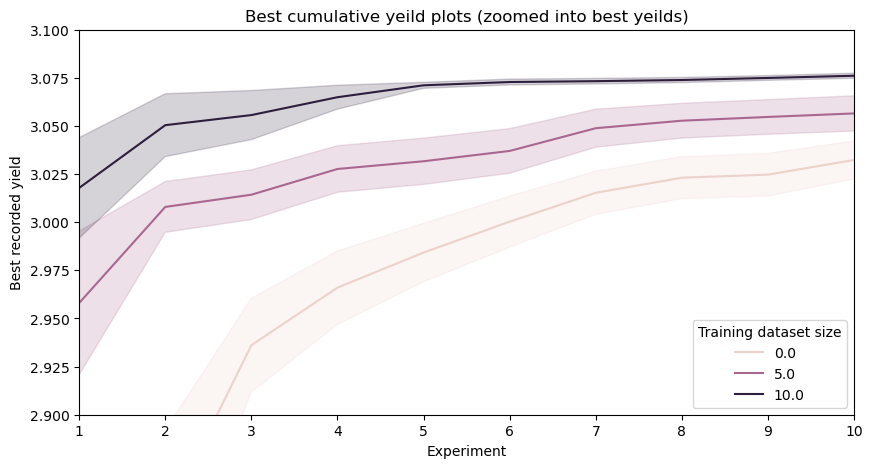

In [9]:
plt.figure(figsize=(10, 5))
plt.ylim([2.9, 3.1])
plt.xlim([1, 10])
sns.lineplot(data=results, x="Experiment", y="Best recorded yield", hue="Training dataset size", errorbar="se")
plt.title("Best cumulative yeild plots (zoomed into best yeilds)")
plt.show()

Try to recreate the above experiments under different conditions. For instance, try changing the parameters `compass_offset`, `shift_offset` and `approximation_error_size`. As these parameters increase, discrepancy between the true gold map and Rikard's reconstruction will also increase, and the advantage of the training data over single-task BO should diminish. TLBO may postentially become counterproductive if the tasks have little to do with each other around the optima. 

# Afterthought: why do we care about TLBO at Novo? 

Related optimization tasks appear in both experimental and computational biochemistry all the time. A few examples where TLBO could prove useful are described below: 
- Optimizing molecules for binding affinity with a protein given previous optimization with a similar protein. 
- Utilizing large datasets of low-fidelity experiments to inform finer-grained optimization. 

## Customizing the MTSuggestor for general situations

The XpyriMentor framework is highly modular and customizable, and continues to become even more so. Below we hardcode the attributes (to their default values in the walkthrough above) to show the properties that can be altered. In particular the user should put some thought into the mean and kernel functions, likelihood function, acquisition function and relative lengthscales when designing their XpyriMentor as an informed choice will significantly improve the learning rate and advantage of the training data. 

Note that these defaults are selected depending on your space to fit the dimension and boundary widths. 

In [10]:
# Libraries for the kernels we're using - one can easily add others
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
import torch

multitask_space = po.Space([(0.0, 15.0), (0.0, 15.0), [0,1,{1}]])

RikardsMTSuggestor = MTSuggestor(multitask_space, 1, 42)

RikardsMentor = XpyriMentor(multitask_space, RikardsMTSuggestor)

RikardsMentor.suggestor.kwargs['surrogate_kwargs'] = {}
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['type'] = 'multitask'

# These defaults are determined by multitask_space upon __init__ of suggestor. 
# Task feature could be changed during BO experiment
RikardsMentor.suggestor.tasks = 2
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['task_feature'] = 2

# Custom acquisition function
RikardsMentor.suggestor.kwargs['acq_func_kwargs'] = {}
RikardsMentor.suggestor.kwargs['acq_func_kwargs']['acq'] = 'qLogExpectedImprovement'

# Custom surrogate model
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['likelihood'] = GaussianLikelihood()
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['mean_module'] = ConstantMean()

base_kernel = RBFKernel(ard_num_dims=2)

# The relative lengthscale of changes in the acquisition function to the boundary widths.
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['covar_relative_lengthscale'] = 0.2

# Retrieving boundary widths for hardcoding the lengthscale in a custom kernel
task_feature = RikardsMentor.suggestor.kwargs.get('surrogate_kwargs').get('task_feature')
non_task_indices = [i for i in range(RikardsMentor.suggestor.space.n_dims)]
non_task_indices.remove(task_feature)
non_task_bound_widths = [RikardsMentor.suggestor.space.bounds[i][1] - RikardsMentor.suggestor.space.bounds[i][0] for i in non_task_indices]

# Hardcoding the relative lengthscale into a custom kernel
rel_lengthscale = RikardsMentor.suggestor.kwargs.get('surrogate_kwargs').get('covar_relative_lengthscale')
base_kernel.lengthscale = torch.tensor([[width*rel_lengthscale for width in non_task_bound_widths]])

# The covaraince kernel can be tailored explicitly or through the 'rel_lengthscale' above.
RikardsMentor.suggestor.kwargs['surrogate_kwargs']['covar_module'] = ScaleKernel(base_kernel)